<>:84: SyntaxWarning: invalid escape sequence '\m'
<>:91: SyntaxWarning: invalid escape sequence '\m'
<>:84: SyntaxWarning: invalid escape sequence '\m'
<>:91: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_11617/576448789.py:84: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_ylabel('Amplitud ($\mu V$)')
/tmp/ipykernel_11617/576448789.py:91: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_ylabel('Amplitud ($\mu V$)')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Iniciando lectura de archivos...
Lectura completada. Total de registros cargados: 500


/tmp/ipykernel_11617/576448789.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_labels, x='Clase', palette=['#3498db', '#e74c3c'], order=['No ictal', 'Ictal'])


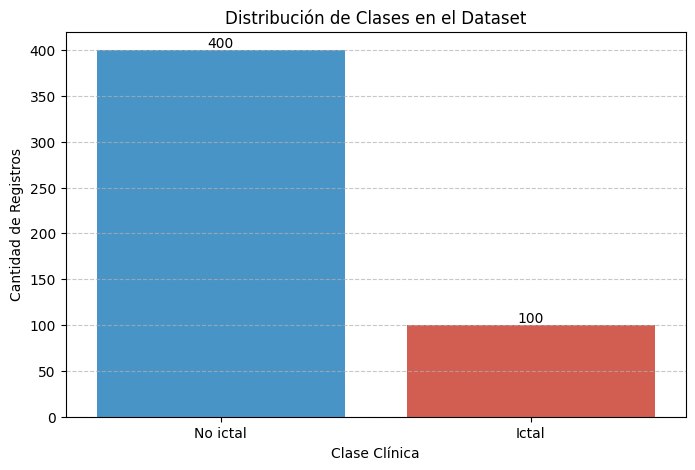

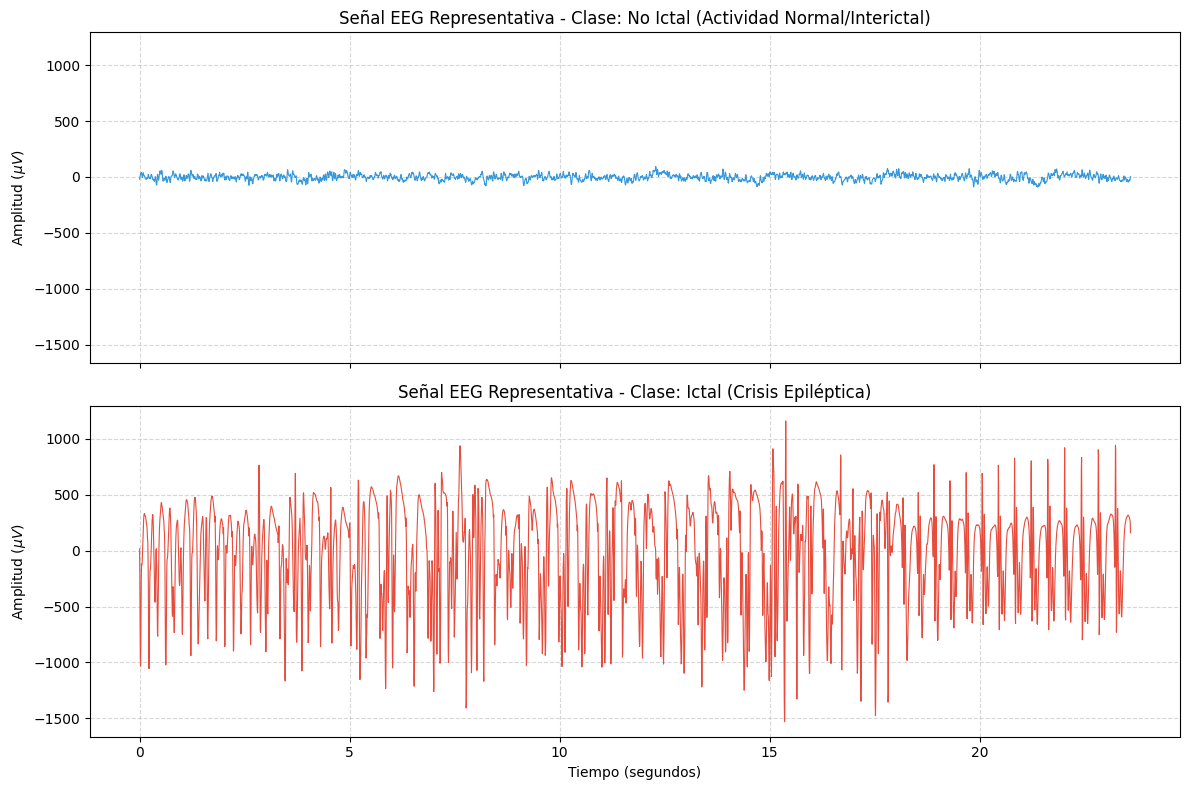


Calculando estadísticas descriptivas...

Estadísticas Descriptivas Promedio por Clase:


,Media,Desviación Estándar,Varianza,Mínimo,Máximo,Asimetría (Skewness),Curtosis
Clase,,,,,,,
Ictal,-4.749,306.573,115659.632,-948.910,910.050,-0.060,0.428
No ictal,-8.464,54.567,4088.426,-205.945,194.472,-0.009,0.603


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from google.colab import drive

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Definición de rutas y parámetros
# Ajuste de ruta según el directorio proporcionado
base_path = '/content/drive/MyDrive/Proyecto_RecPatrones/Avance_2/Dataset-BONN'

# Mapeo de carpetas según el planteamiento binario (Bonn EEG)
# Z (A), O (B), N (C), F (D) -> No ictal
# S (E) -> Ictal
folder_mapping = {
    'Z': 'No ictal',
    'O': 'No ictal',
    'N': 'No ictal',
    'F': 'No ictal',
    'S': 'Ictal'
}

# Parámetros fisiológicos
fs = 173.61 # Frecuencia de muestreo en Hz
n_samples = 4097 # Muestras por segmento

# 3. Carga de datos
data_signals = []
labels = []

print("Iniciando lectura de archivos...")
for folder, label in folder_mapping.items():
    folder_path = os.path.join(base_path, folder)

    if os.path.exists(folder_path):
        files = os.listdir(folder_path)
        for filename in files:
            file_path = os.path.join(folder_path, filename)
            try:
                # Los archivos del dataset de Bonn contienen una columna de datos en texto plano
                signal = np.loadtxt(file_path)
                data_signals.append(signal)
                labels.append(label)
            except Exception as e:
                print(f"Error al leer el archivo {file_path}: {e}")
    else:
        print(f"Advertencia: No se encontró la ruta {folder_path}")

print(f"Lectura completada. Total de registros cargados: {len(labels)}")

# 4. Distribución de Clases
df_labels = pd.DataFrame({'Clase': labels})

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_labels, x='Clase', palette=['#3498db', '#e74c3c'], order=['No ictal', 'Ictal'])
plt.title('Distribución de Clases en el Dataset')
plt.xlabel('Clase Clínica')
plt.ylabel('Cantidad de Registros')

# Añadir etiquetas de cantidad sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. Visualización de Muestras Representativas
# Vector de tiempo (23.6 segundos)
time_vector = np.arange(n_samples) / fs

# Identificar el índice del primer registro de cada clase
idx_no_ictal = labels.index('No ictal')
idx_ictal = labels.index('Ictal')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)

# Gráfica señal No Ictal
axes[0].plot(time_vector, data_signals[idx_no_ictal], color='#3498db', linewidth=0.8)
axes[0].set_title('Señal EEG Representativa - Clase: No Ictal (Actividad Normal/Interictal)')
axes[0].set_ylabel('Amplitud ($\mu V$)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfica señal Ictal
axes[1].plot(time_vector, data_signals[idx_ictal], color='#e74c3c', linewidth=0.8)
axes[1].set_title('Señal EEG Representativa - Clase: Ictal (Crisis Epiléptica)')
axes[1].set_xlabel('Tiempo (segundos)')
axes[1].set_ylabel('Amplitud ($\mu V$)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 6. Estadísticas Descriptivas
print("\nCalculando estadísticas descriptivas...")
stats_list = []

for signal, label in zip(data_signals, labels):
    stats = {
        'Clase': label,
        'Media': np.mean(signal),
        'Desviación Estándar': np.std(signal),
        'Varianza': np.var(signal),
        'Mínimo': np.min(signal),
        'Máximo': np.max(signal),
        'Asimetría (Skewness)': skew(signal),
        'Curtosis': kurtosis(signal)
    }
    stats_list.append(stats)

df_stats = pd.DataFrame(stats_list)

# Agrupación por clase para obtener un resumen estadístico global
summary_stats = df_stats.groupby('Clase').mean().round(3)

print("\nEstadísticas Descriptivas Promedio por Clase:")
display(summary_stats)

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')

# Rutas y configuración
base_path = '/content/drive/MyDrive/proyecto_patrones/Dataset'

# Mapeo de carpetas a los subconjuntos del dataset de Bonn
folder_mapping = {
    'Z': 'Set A (Sano - Ojos Abiertos)',
    'O': 'Set B (Sano - Ojos Cerrados)',
    'N': 'Set C (Interictal - Región Control)',
    'F': 'Set D (Interictal - Zona Focal)',
    'S': 'Set E (Ictal - Crisis Activa)'
}

data_stats = []

print("Procesando archivos para análisis detallado...")

for folder, label in folder_mapping.items():
    folder_path = os.path.join(base_path, folder)

    if os.path.exists(folder_path):
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            try:
                signal = np.loadtxt(file_path)

                # Cálculo de métricas por cada segmento EEG
                stats = {
                    'Subconjunto': label,
                    'Media': np.mean(signal),
                    'Max_Amplitud': np.max(signal),
                    'Asimetria': skew(signal),
                    'Curtosis': kurtosis(signal) # Fisher (exceso de curtosis), normal = 0
                }
                data_stats.append(stats)
            except Exception as e:
                pass

df_detailed = pd.DataFrame(data_stats)

# Agrupación para obtener la media y desviación estándar de cada métrica por subconjunto
agg_funcs = {
    'Media': ['mean', 'std'],
    'Max_Amplitud': ['mean', 'std'],
    'Asimetria': ['mean', 'std'],
    'Curtosis': ['mean', 'std']
}

summary_table = df_detailed.groupby('Subconjunto').agg(agg_funcs).round(2)

# Formateo de la tabla de salida para visualizar "Media ± Desviación Estándar"
formatted_table = pd.DataFrame()
for col in ['Media', 'Max_Amplitud', 'Asimetria', 'Curtosis']:
    formatted_table[col] = summary_table[col]['mean'].astype(str) + " ± " + summary_table[col]['std'].astype(str)

print("\nTabla Resumen de Parámetros Estadísticos:")
display(formatted_table)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Procesando archivos para análisis detallado...

Tabla Resumen de Parámetros Estadísticos:


,Media,Max_Amplitud,Asimetria,Curtosis
Subconjunto,,,,
Set A (Sano - Ojos Abiertos),-6.26 ± 24.82,139.29 ± 48.87,-0.02 ± 0.11,0.23 ± 0.27
Set B (Sano - Ojos Cerrados),-12.51 ± 30.72,214.15 ± 67.71,0.06 ± 0.13,0.22 ± 0.27
Set C (Interictal - Región Control),-8.88 ± 24.12,171.74 ± 92.0,-0.15 ± 0.27,0.65 ± 0.63
Set D (Interictal - Zona Focal),-6.2 ± 23.52,252.71 ± 282.53,0.08 ± 0.76,1.32 ± 2.6
Set E (Ictal - Crisis Activa),-4.75 ± 27.16,910.05 ± 440.93,-0.06 ± 0.76,0.43 ± 1.19
